# Example of Gene Expression Copy Number Correction

May 30, 2024

## Goal:
Apply the copy number correction procedure described in the toy replication notebook. This time applied to genes

**Notes:**
Gene counts will be taken from the previously computed deconvolved f matrices. Replication profiles have been previously computed for all 10k windows. Gene's are assigned to specific 10k windows.

Normalization will be based on genome only. In that the replication profiles will be subset to only include the genes. This is for simplicity because we do not have deconvolved profiles for intergenic regions at the moment.

**Procedure:**
1. Collect the total read counts for all genes for all timepoints into a matrix of size
    (# of genes x deconvolved timepoints) ~ 5500x187 
2. Collect the replication profile for these genes: Look up the 10k bin for each gene into a replication profile matrix of the same dimension:
    (# of genes x deconvolved timepoints) ~ 5500x187
3. Perform copy number correction on the read counts to retrieve a new read count matrix:
    (# of genes x deconvolved timepoints) ~ 5500x187
    
**Expectation:**
- For each gene there will be a sharp decrease in reads at replication time, maybe it will be less dramatic if the size of the genome and number of genes replicating dampens the replication affect on the read count.
- When plotting a gene with unchanging expression: This jump in read count will be the most clear. Plot some control genes in which the gene expression did not appear to change prior to copy number normalization.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [107]:
# Load the gene expression data
# Load the replicating timing data

# For all gene's compute the total number of reads for each sample
# The total reads we will normalize to

# For a given gene load the gene expression data
# Normalize by copy number (at replication time to the end of the cell cycle)
# Reduce the number of reads by half
# Then scale by the total reads

from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_delta_2024_05_27/gene_expression/')
ge_analysis.load_gene_expression_fs()


In [108]:
# Normalize the deconvolved gene expression
# such that all timepoints have equal number of total reads
# a la relative abundance of TPM:
total_reads_per_time = 1e6 # 1 million reads per sample for each gene

normalized_gene_expression_f = ge_analysis.gene_expression_f / \
    ge_analysis.gene_expression_f.sum(axis=0).values.reshape((1, -1))*total_reads_per_time

In [109]:
from src.mnase_replication_timing_analysis import get_bin_for_position
from src.geneset import get_deconvolved_geneset
    
def get_gene_replication_profile(orf_name):
    """Get the replication profile for a given orf. Note the profile returned
    using the Delta-DG1 model.
    
    Loads the deconvolved profile for the given gene orf, from the gene's 
    assigned bin
    
    Returns vector of the deconvolved profile [1 and 2's representing the copy number
    at each timepoint]
    """
    repl_profile = pd.read_csv('datasets/computed_mnase/deconvolved_all_chr_replication_profile_delta_model.csv')
    repl_profile = repl_profile.set_index(['chr', 'start'])

    from src.geneset import get_deconvolved_geneset
    
    geneset = get_deconvolved_geneset()
    gene = geneset.loc[orf_name]
    chrom = gene.chr
    start_indices = repl_profile.loc[chrom].index.values

    chrom_repl_profile = repl_profile.loc[chrom]
    bin_idx, bin_start_bp = get_bin_for_position(gene.TSS, start_indices)
    gene_repl_profil = chrom_repl_profile.loc[bin_start_bp]
    gene_repl_profil.index = gene_repl_profil.index.astype(int)
    
    return gene_repl_profil
    

In [110]:
from src.timer import Timer

timer = Timer()
geneset = get_deconvolved_geneset()

copy_num_corr_expression_f = normalized_gene_expression_f.copy()

i = 0
n = len(normalized_gene_expression_f)
for orf_name, row in normalized_gene_expression_f.iterrows():

    repl_prof = get_gene_replication_profile(orf_name)
    expression_f = normalized_gene_expression_f.loc[orf_name]
    copy_num_corr_expression_f.loc[orf_name] = expression_f / repl_prof

    if i % 200 == 0:
        timer.print_time(f"{i}/{n}")
    i += 1


0/3750 - 00:00:00.107
200/3750 - 00:00:14.395
400/3750 - 00:00:28.561
600/3750 - 00:00:42.699
800/3750 - 00:00:56.888
1000/3750 - 00:01:11.109
1200/3750 - 00:01:25.206
1400/3750 - 00:01:39.650
1600/3750 - 00:01:53.705
1800/3750 - 00:02:07.849
2000/3750 - 00:02:22.018
2200/3750 - 00:02:36.565
2400/3750 - 00:02:51.036
2600/3750 - 00:03:06.115
2800/3750 - 00:03:21.228
3000/3750 - 00:03:37.465
3200/3750 - 00:03:53.359
3400/3750 - 00:04:10.269
3600/3750 - 00:04:25.043


In [114]:
ge_analysis.gene_expression_f.sum(axis=0)

0      40321.007254
1      40328.998011
2       40344.81395
3      40368.921745
4      40400.476139
           ...     
183    40456.237104
184    40457.233831
185    40457.889532
186    40458.202393
187    37473.677624
Length: 188, dtype: object

(0.0, 50000.0)

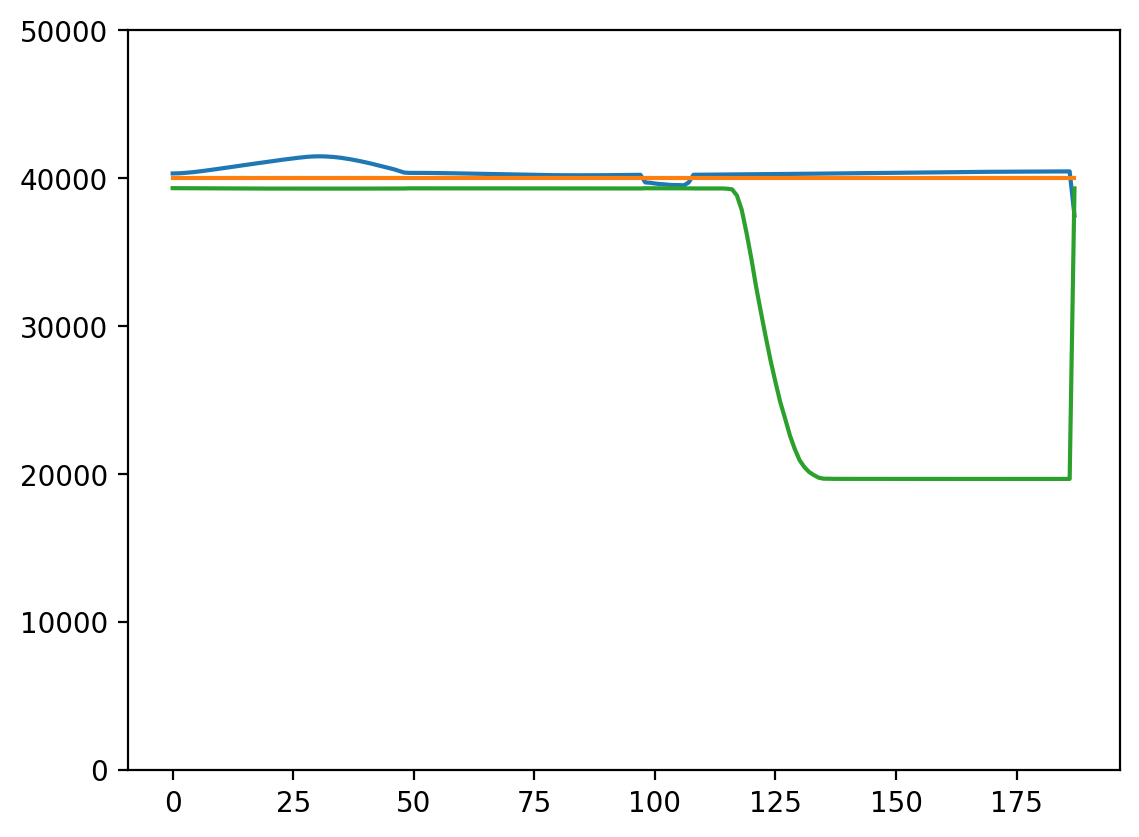

In [116]:
plt.figure()


plt.plot(ge_analysis.gene_expression_f.sum(axis=0))
plt.plot(normalized_gene_expression_f.sum(axis=0) / 1e6 * 40000)
plt.plot(copy_num_corr_expression_f.sum(axis=0) / 1e6 * 40000)
plt.ylim(0, 50000)

In [119]:
# Testing copy number correction procedure for all genes
# Note: this is against the old CG1, DG1 model
# and thus the timing of S will have a different index
# than the Delta-DG1 model. Going forward, we will use the Delta-DG1 model

In [129]:
# July 3, 2024
# A set of genes did not deconvolve properly because of the updated
# deconvolution method, will need to rerun for these 2000 genes

failed_deconvolved_orfs = list(set(geneset.index).difference(set(normalized_gene_expression_f.index)))
geneset['index'] = np.arange(len(geneset))
failed_geneset_20240603 = geneset.loc[failed_deconvolved_orfs].sort_values('index')
failed_geneset_20240603.to_csv('output/deconvolve_combined_delta_2024_05_27/rerun_geneset.csv')
len(failed_geneset_20240603)

1828